In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [83]:
df = pd.read_csv('ebola_2014_2016_clean.csv')
df.head()

,Country,Date,No. of confirmed cases,No. of confirmed deaths
0,Guinea,2014-08-29,482.0,287.0
1,Nigeria,2014-08-29,15.0,6.0
2,Sierra Leone,2014-08-29,935.0,380.0
3,Liberia,2014-08-29,322.0,225.0
4,Guinea,2014-09-05,604.0,362.0


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  2484 non-null   object 
 1   Date                     2484 non-null   object 
 2   No. of confirmed cases   2484 non-null   float64
 3   No. of confirmed deaths  1648 non-null   float64
dtypes: float64(2), object(2)
memory usage: 77.8+ KB


In [85]:
df.isnull().sum()

Country                      0
Date                         0
No. of confirmed cases       0
No. of confirmed deaths    836
dtype: int64

In [86]:
df.shape

(2484, 4)

## Drop all columns with missing values to clean the dataset

In [87]:
df.dropna(inplace=True)
df.shape

(1648, 4)

In [88]:
df.isnull().sum()

Country                    0
Date                       0
No. of confirmed cases     0
No. of confirmed deaths    0
dtype: int64

In [89]:
df["Country"].value_counts()

Country
Guinea                      257
Sierra Leone                257
Nigeria                     255
Senegal                     254
United States of America    245
Spain                       243
Liberia                     125
Mali                          9
United Kingdom                2
Italy                         1
Name: count, dtype: int64

In [90]:
df.columns

Index(['Country', 'Date', 'No. of confirmed cases', 'No. of confirmed deaths'], dtype='object')

## Visialize the growth of Ebola in the different countries using subplots

In [91]:
countries = sorted(df["Country"].unique())
countries

['Guinea',
 'Italy',
 'Liberia',
 'Mali',
 'Nigeria',
 'Senegal',
 'Sierra Leone',
 'Spain',
 'United Kingdom',
 'United States of America']

In [92]:
# Determine subplot layout
n_countries = len(countries)
ncols = 2
nrows = (n_countries + ncols - 1) // ncols
print(f"Number of countries: {n_countries}, Subplot layout: {nrows} rows x {ncols} columns")

Number of countries: 10, Subplot layout: 5 rows x 2 columns


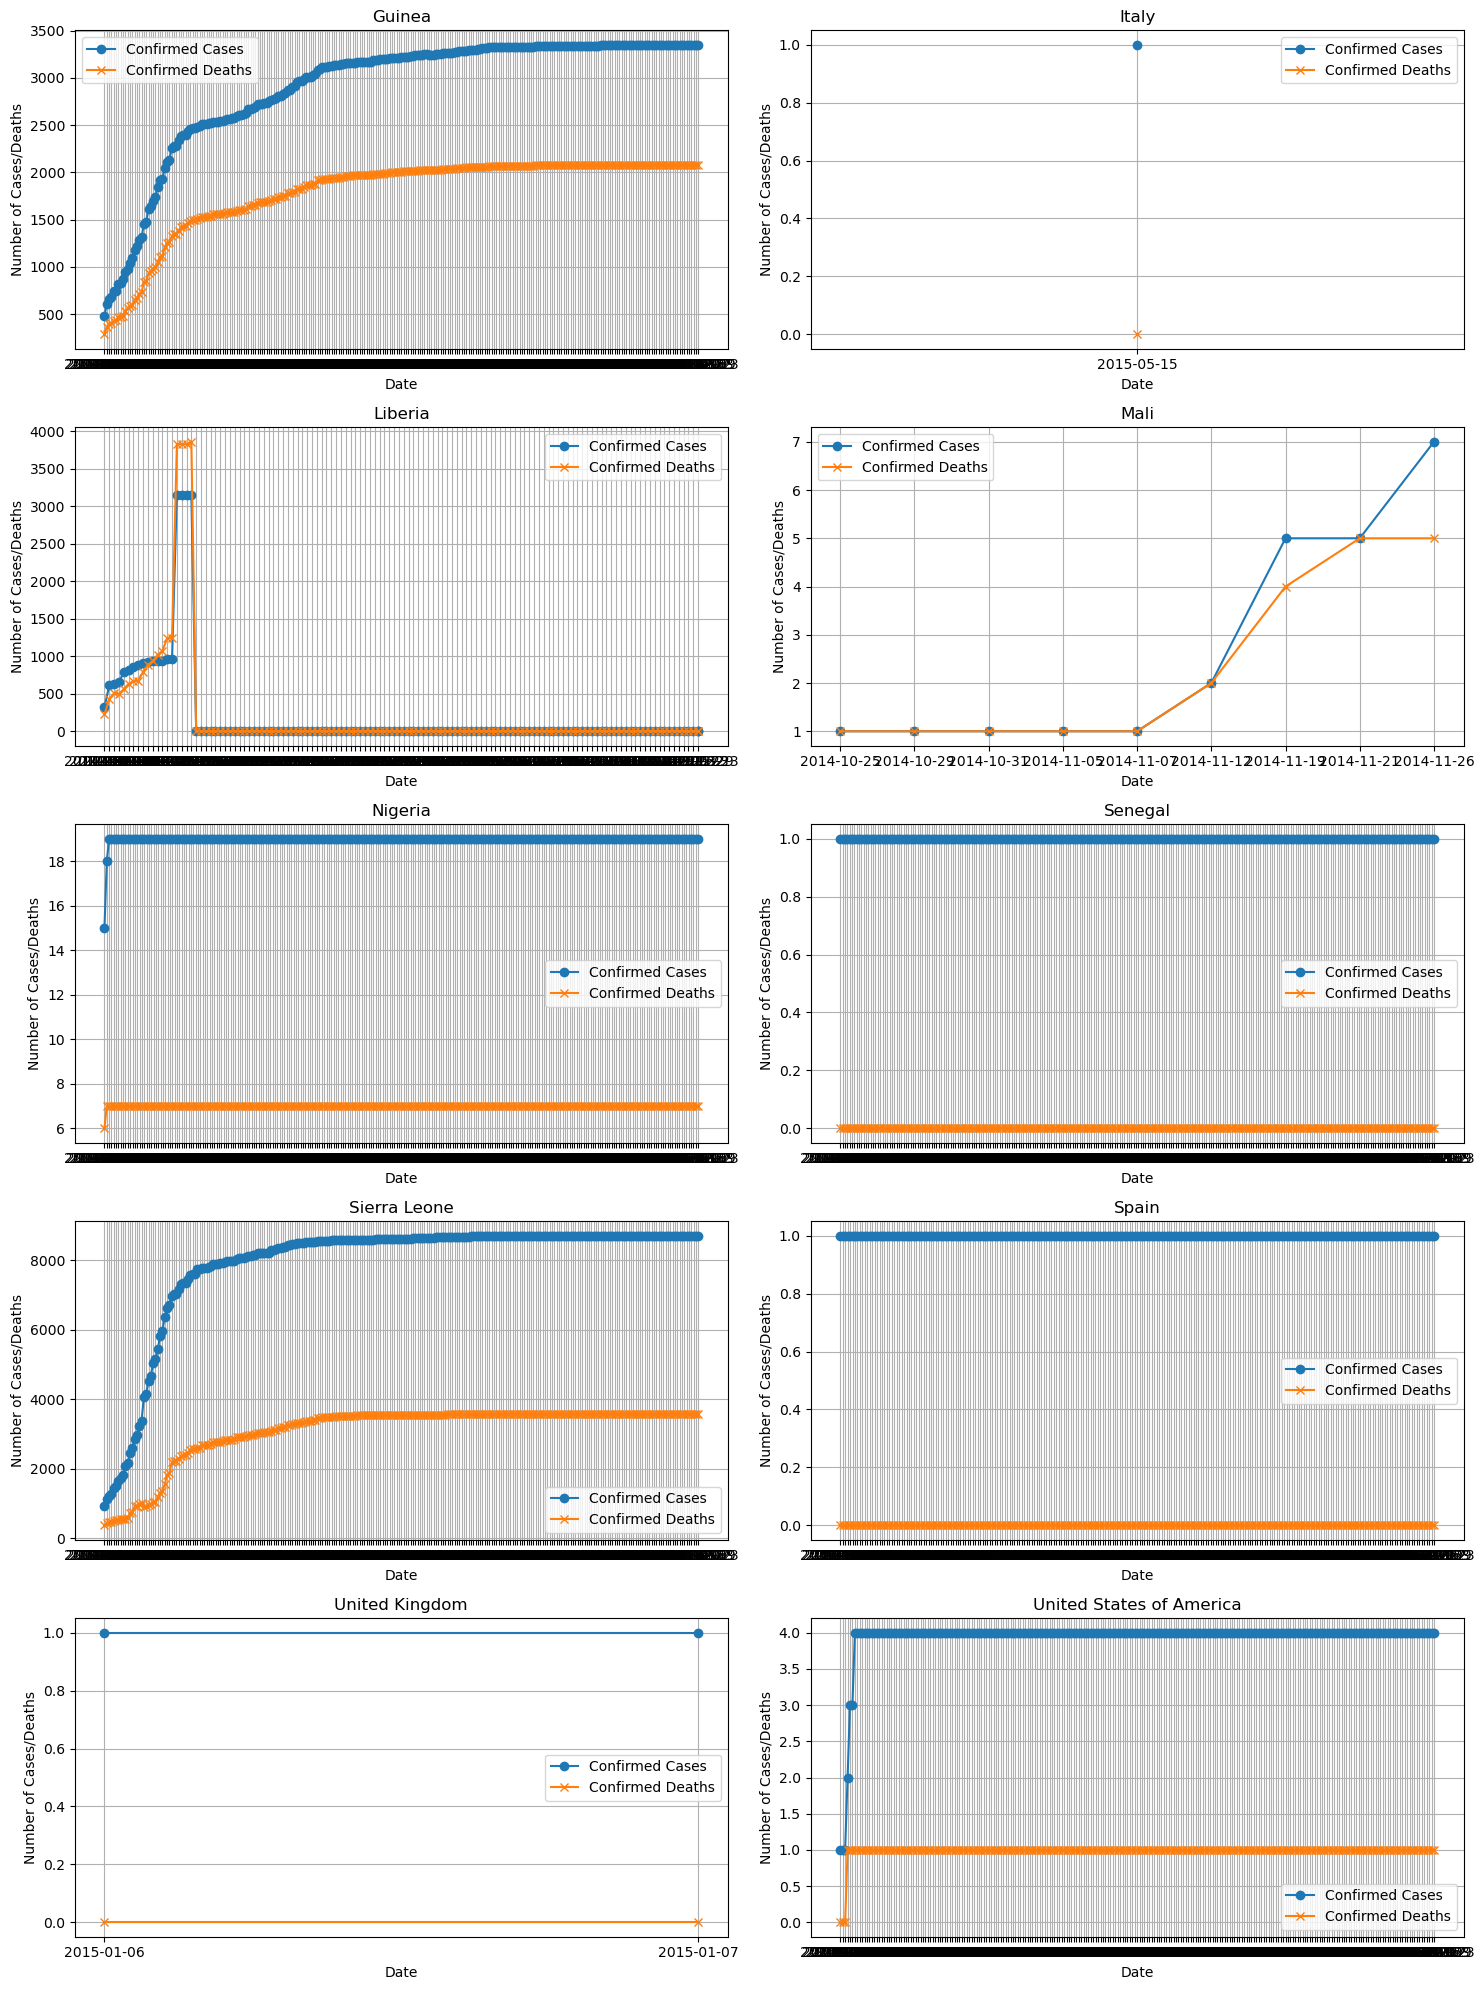

In [93]:
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 20),
    sharex=False
)

axes = axes.flatten()

for ax, country in zip(axes, countries):
    country_data = df[df["Country"] == country]

    ax.plot(
        country_data["Date"],
        country_data["No. of confirmed cases"],
        marker='o',
        label='Confirmed Cases'
    )

    ax.plot(
        country_data["Date"],
        country_data["No. of confirmed deaths"],
        marker='x',
        label='Confirmed Deaths'
    )

    ax.set_title(country)
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of Cases/Deaths")
    ax.legend()
    ax.grid(True)

# Remove any unused subplots
for i in range(len(countries), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

 ## Guinea case study

AttributeError: PathCollection.set() got an unexpected keyword argument 'xlabel'

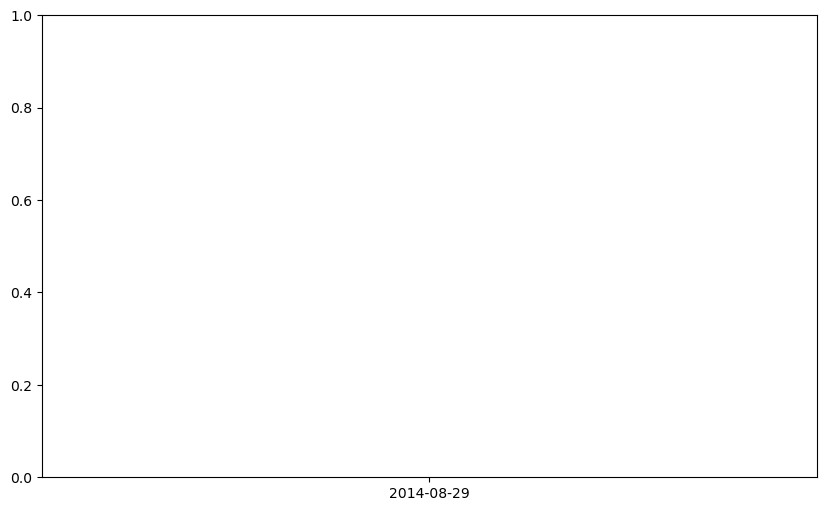

In [ ]:
guinea_data = df[df["Country"] == "Guinea"]
plt.figure(figsize=(10, 6))
g1=plt.scatter(
    guinea_data["Date"],
    guinea_data["No. of confirmed cases"],
    color='blue'
)
plt.scatter(
    guinea_data["Date"],
    guinea_data["No. of confirmed deaths"],
    color='red'
    ax=g1
)
plt.title("Ebola Cases and Deaths in Guinea (2014-2016)")
plt.xlabel("Date")
plt.ylabel("Number of Cases/Deaths")
plt.legend()
plt.show()